In [2]:
import pandas as pd
import seaborn
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

In [3]:
lang_compare = pd.read_csv("metrics.csv", index_col=0)
baseline_compare = pd.read_csv("baseline_compare_metrics.csv", index_col=0)

In [4]:
lang_compare.head() # compare between languages eg french1<->english1, french2<->english2, french3<->english3 ... 
                    # and between baselines eg baseline_french1<->baseline_english1 ...

,Model,Question,Cosine,fBaseline,Language1-Language2
0,Qwen3-32B,Question 1,0.9332,False,NL-EN
1,Qwen3-32B,Question 1,0.9332,False,NL-EN
2,Qwen3-32B,Question 1,0.9332,False,NL-EN
3,Qwen3-32B,Question 1,0.9332,False,NL-EN
4,Qwen3-32B,Question 1,0.9332,False,NL-EN


In [5]:
baseline_compare.head() # compare specific language and its baseline eg french1<->baseline_french1, french2<->baseline_french2 ...

,Model,Question,Language,Cosine,Rouge
0,Qwen3-32B,Question 1,NL,0.9603,0.2708
1,Qwen3-32B,Question 1,NL,0.9603,0.2708
2,Qwen3-32B,Question 1,NL,0.9603,0.2708
3,Qwen3-32B,Question 1,NL,0.9603,0.2708
4,Qwen3-32B,Question 1,NL,0.9603,0.2708


In [6]:
lang_compare.drop("Question", axis=1).groupby(["Model","Language1-Language2", "fBaseline"]).agg(['mean', 'std', 'count'])

Cosine                
                                             mean       std count
Model     Language1-Language2 fBaseline                          
Qwen3-32B EN-FR               False      0.839300  0.050925   800
                              True       0.848500  0.037405   800
          NL-EN               False      0.802112  0.111944   800
                              True       0.851087  0.042964   800
          NL-FR               False      0.763675  0.109649   800
                              True       0.810100  0.038951   800

In [7]:
lang_compare.groupby(["Model","Question","Language1-Language2", "fBaseline"]).agg(['mean', 'std', 'count'])

Cosine           
                                                      mean  std count
Model     Question   Language1-Language2 fBaseline                   
Qwen3-32B Question 1 EN-FR               False      0.8794  0.0   100
                                         True       0.8983  0.0   100
                     NL-EN               False      0.9332  0.0   100
                                         True       0.9351  0.0   100
                     NL-FR               False      0.8958  0.0   100
                                         True       0.8934  0.0   100
          Question 2 EN-FR               False      0.9060  0.0   100
                                         True       0.8816  0.0   100
                     NL-EN               False      0.5932  0.0   100
                                         True       0.7952  0.0   100
                     NL-FR               False      0.5472  0.0   100
                                         True       0.7435  0.0   100
          Question 3 EN-FR               False      0.8066  0.0   100
                                         True       0.8320  0.0   100
                     NL-EN               False      0.8492  0.0   100
                                         True       0.8359  0.0   100
                     NL-FR               False      0.7775  0.0   100
                                         True       0.8098  0.0   100
          Question 4 EN-FR               False      0.7861  0.0   100
                                         True       0.8193  0.0   100
                     NL-EN               False      0.6554  0.0   100
                                         True       0.8054  0.0   100
                     NL-FR               False      0.6447  0.0   100
                                         True       0.8061  0.0   100
          Question 5 EN-FR               False      0.8726  0.0   100
                                         True       0.9069  0.0   100
                     NL-EN               False      0.8842  0.0   100
                                         True       0.8350  0.0   100
                     NL-FR               False      0.8209  0.0   100
                                         True       0.7847  0.0   100
          Question 6 EN-FR               False      0.7464  0.0   100
                                         True       0.8129  0.0   100
                     NL-EN               False      0.7718  0.0   100
                                         True       0.8949  0.0   100
                     NL-FR               False      0.7899  0.0   100
                                         True       0.8114  0.0   100
          Question 7 EN-FR               False      0.8469  0.0   100
                                         True       0.8179  0.0   100
                     NL-EN               False      0.8641  0.0   100
                                         True       0.8590  0.0   100
                     NL-FR               False      0.7542  0.0   100
                                         True       0.8188  0.0   100
          Question 8 EN-FR               False      0.8704  0.0   100
                                         True       0.8191  0.0   100
                     NL-EN               False      0.8658  0.0   100
                                         True       0.8482  0.0   100
                     NL-FR               False      0.8792  0.0   100
                                         True       0.8131  0.0   100

In [8]:
baseline_compare.drop("Question", axis=1).groupby(["Model", "Language"]).agg(["mean", "count"])

Cosine           Rouge      
                        mean count      mean count
Model     Language                                
Qwen3-32B EN        0.910325   800  0.308262   800
          FR        0.880263   800  0.261763   800
          NL        0.805662   800  0.218900   800

In [9]:
baseline_compare.groupby(["Model", "Question", "Language"]).agg(["mean", "count"])

Cosine         Rouge      
                                 mean count    mean count
Model     Question   Language                            
Qwen3-32B Question 1 EN        0.9709   100  0.3636   100
                     FR        0.9410   100  0.2967   100
                     NL        0.9603   100  0.2708   100
          Question 2 EN        0.9468   100  0.2752   100
                     FR        0.9127   100  0.2616   100
                     NL        0.6133   100  0.1704   100
          Question 3 EN        0.7748   100  0.1699   100
                     FR        0.7717   100  0.1915   100
                     NL        0.8011   100  0.2158   100
          Question 4 EN        0.8487   100  0.2462   100
                     FR        0.8171   100  0.1429   100
                     NL        0.6191   100  0.1704   100
          Question 5 EN        0.9642   100  0.5556   100
                     FR        0.9268   100  0.3003   100
                     NL        0.8318   100  0.2181   100
          Question 6 EN        0.8682   100  0.2827   100
                     FR        0.8466   100  0.2171   100
                     NL        0.7944   100  0.1946   100
          Question 7 EN        0.9535   100  0.2607   100
                     FR        0.9343   100  0.4611   100
                     NL        0.9221   100  0.2467   100
          Question 8 EN        0.9555   100  0.3122   100
                     FR        0.8919   100  0.2229   100
                     NL        0.9032   100  0.2644   100

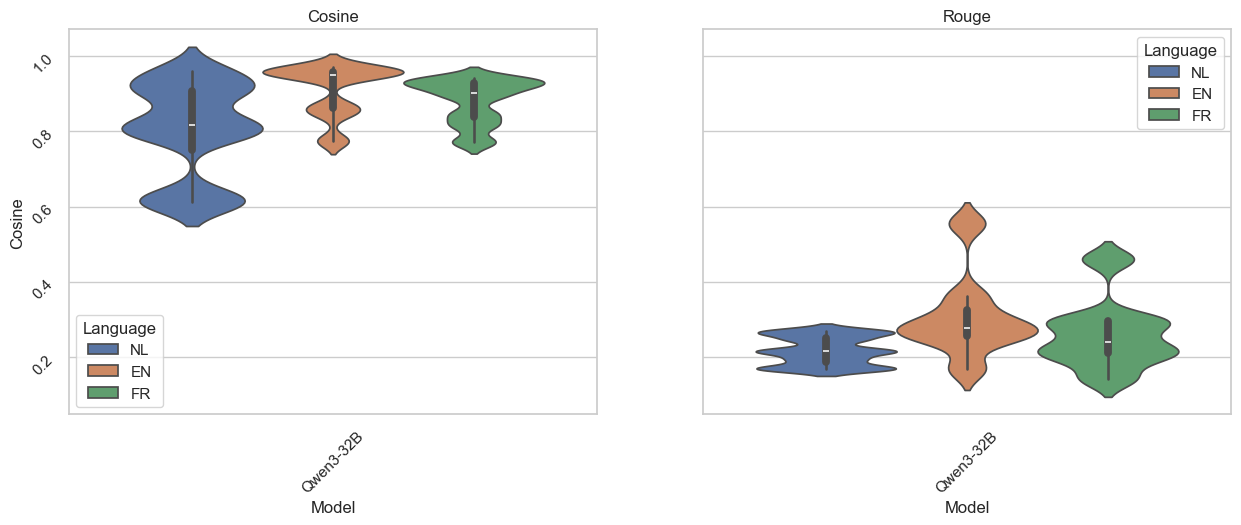

In [10]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]
fig, axs = plt.subplots(ncols=len(ys), figsize=(15,5), sharey=True)

# not between questions, each violin plot has 24 data points
for i in range(len(ys)):
    axs[i].tick_params(labelrotation=45)   
    axs[i].title.set_text(ys[i])
    seaborn.violinplot(x="Model", 
                       y=ys[i], 
                       hue="Language",
                       data=baseline_compare,
                       density_norm='count',
                       ax=axs[i])

TypeError: 'Axes' object is not subscriptable

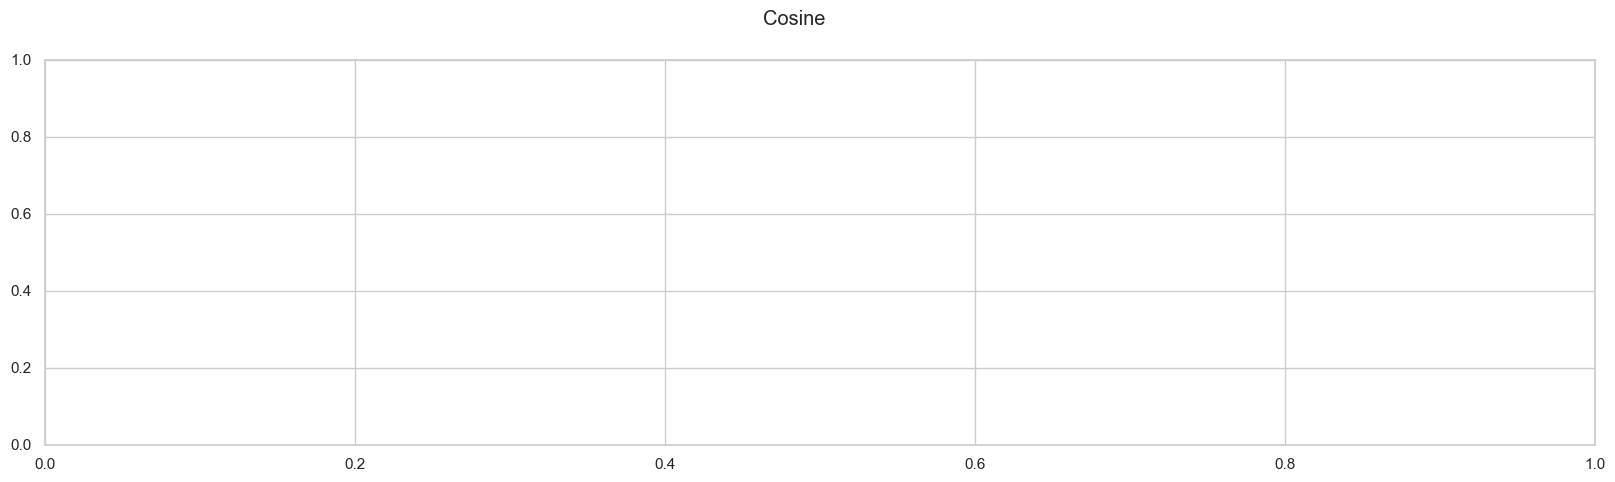

In [11]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]

# between questions, each violin plot only has 3 data points
for y in ys:
    fig, axs = plt.subplots(ncols=len(baseline_compare["Model"].unique()), figsize=(20,5),  sharey=True)
    fig.suptitle(y)
    i = 0
    for model in baseline_compare["Model"].unique():  
        axs[i].title.set_text(model)
        axs[i].tick_params(labelrotation=45)                    
        seaborn.violinplot(x ="Question", 
                           y=y, 
                           hue="Language",
                           data = baseline_compare[baseline_compare["Model"]==model],
                           density_norm='count',
                           ax=axs[i])
        i+=1
    plt.figure()

ValueError: Could not interpret value `Rouge` for `y`. An entry with this name does not appear in `data`.

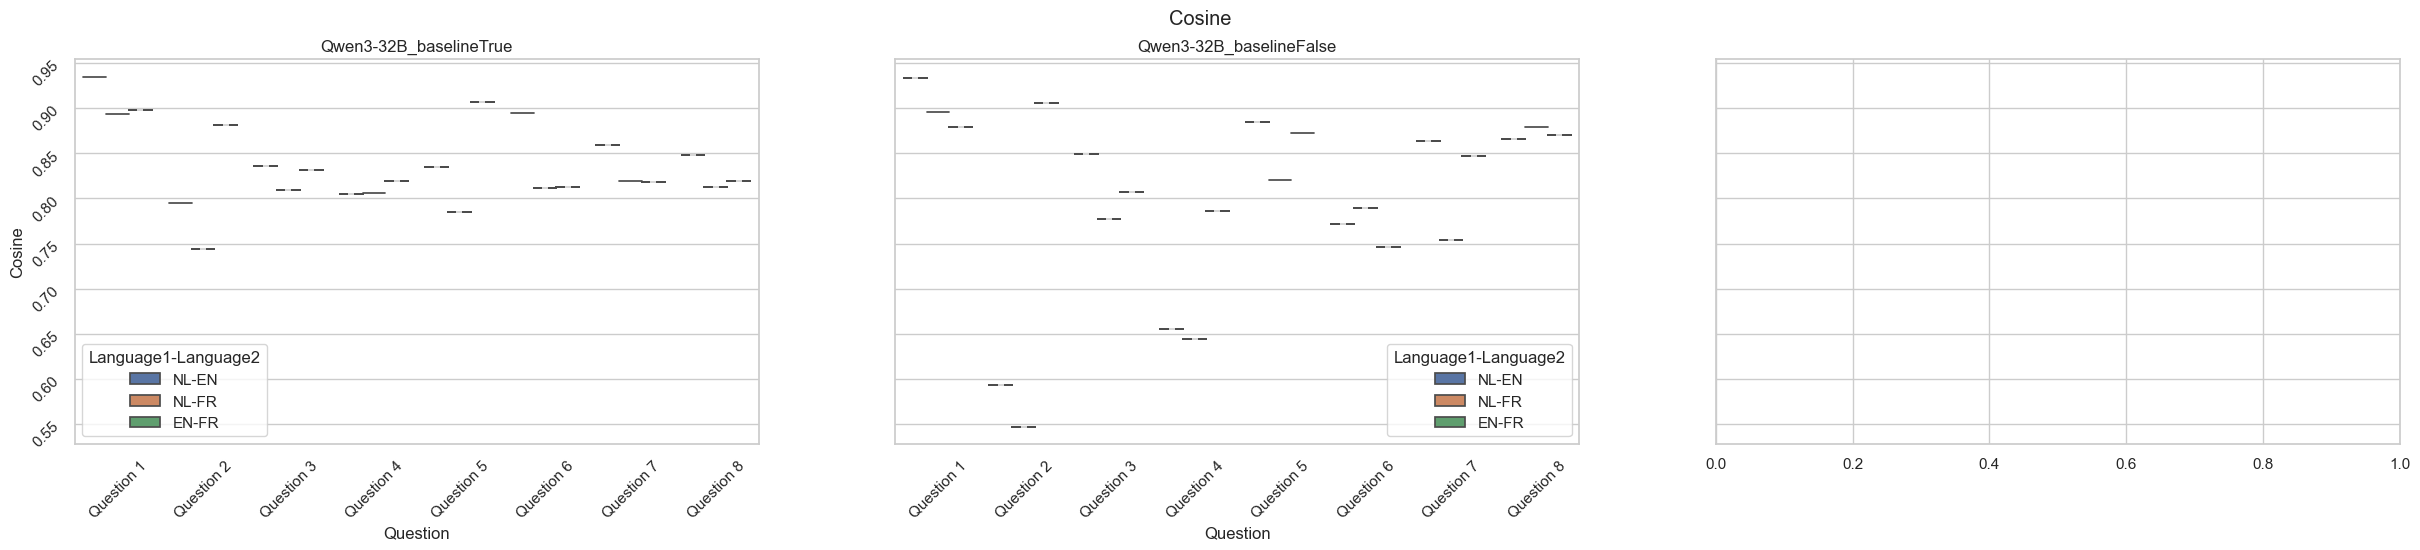

<Figure size 640x480 with 0 Axes>

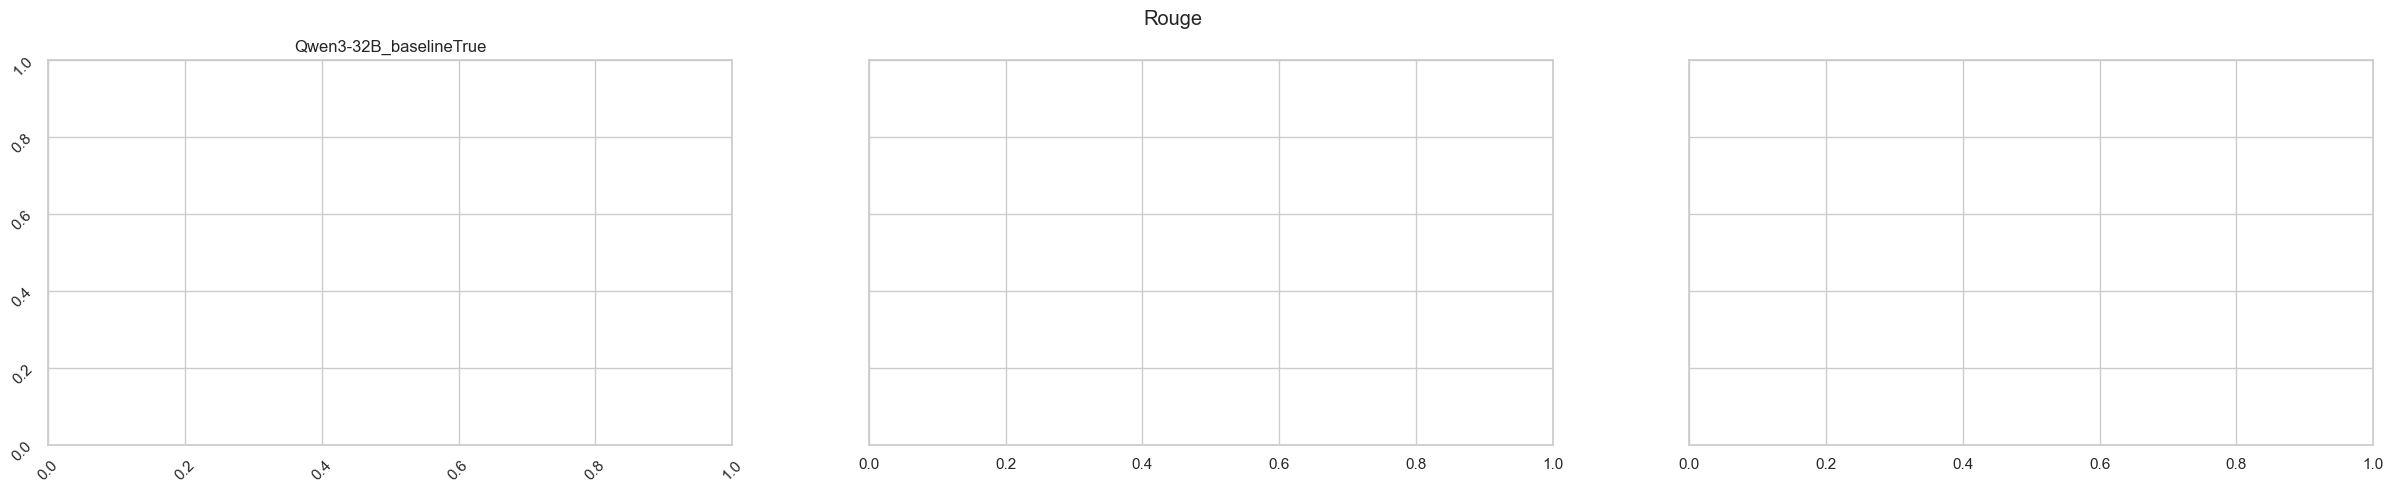

In [12]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]

# between questions, each violin plot only has 3 data points
for y in ys:
    fig, axs = plt.subplots(ncols=len(lang_compare["Model"].unique())+2, figsize=(30,5),  sharey=True)
    fig.suptitle(y)
    i = 0
    for model in lang_compare["Model"].unique():  
        for b in [True, False]:
            axs[i].title.set_text(f"{model}_baseline{b}")
            axs[i].tick_params(labelrotation=45)                    
            seaborn.violinplot(x ="Question", 
                               y=y, 
                               hue="Language1-Language2",
                               data = lang_compare[(lang_compare["Model"]==model)&(lang_compare["fBaseline"]==b)],
                               density_norm='count',
                               ax=axs[i])
            i+=1
    plt.figure()

In [ ]:
seaborn.set(style = 'whitegrid')  
ys = ["Cosine", "Rouge"]

# not between questions, each violin plot has 24 data points
for y in ys:
    fig, axs = plt.subplots(ncols=len(lang_compare["Model"].unique()), figsize=(20,5),  sharey=True)
    fig.suptitle(y)
    i = 0
    for model in lang_compare["Model"].unique():  
        axs[i].title.set_text(f"{model}")
        axs[i].tick_params(labelrotation=45)                    
        seaborn.violinplot(x ="Language1-Language2", 
                           y=y, 
                           hue="fBaseline",
                           data = lang_compare[(lang_compare["Model"]==model)],
                           density_norm='count',
                           ax=axs[i])
        i+=1
    plt.figure()

## See data

In [17]:
from datasets import load_from_disk, concatenate_datasets
import pickle
import json
from glob import glob

paths = glob("t0*")

In [18]:
answers = [load_from_disk(x) for x in paths]
answers = concatenate_datasets(answers)
with open("question_map.pkl", 'rb') as f:
    question_map = pickle.load(f)
with open("params.json", 'r') as f:
    params = json.load(f)
answers = answers.add_column("question_mapped", [question_map[x] for x in answers["question"]])

In [19]:
question_map

{'Wie was Napoleon Bonaparte?': 'Question 1',
 'Was Napoleon Bonaparte een held?': 'Question 2',
 'Was Napoleon Bonaparte een tiran?': 'Question 3',
 'Was Napoleon Bonaparte een schurk?': 'Question 4',
 'Hoe werd Napoleon Bonaparte keizer van Frankrijk?': 'Question 5',
 "Werd Napoleon's aanspraak op keizerschap in Europa gesteund?": 'Question 6',
 "Welke invloed had Napoleon's heerschappij op Engeland en Nederland?": 'Question 7',
 'Was de impact van Napoleons heerschappij op Engeland en Nederland destructief?': 'Question 8',
 'Who was Napoleon Bonaparte?': 'Question 1',
 'Was Napoleon Bonaparte a hero?': 'Question 2',
 'Was Napoleon Bonaparte a tyrant?': 'Question 3',
 'Was Napoleon Bonaparte a villain?': 'Question 4',
 'How did Napoleon Bonaparte become the Emperor of France?': 'Question 5',
 "Was Napoleon's claim to Emperor favoured in Europe?": 'Question 6',
 "How did Napoleon's rule impact England and the Netherlands?": 'Question 7',
 'Was the impact of Napoleon’s rule on England 

In [20]:
answers = answers.to_pandas()

In [28]:
answers["answers"][1][0]

'Niet in de traditie van ridderlijk gedrag of morele superioriteit kan Napoleon Bonaparte als een held worden beschouwd. In de historische context van de documenten die u hebt aangehaald, wordt hij voorgesteld als een tirannieke en agressieve figuur. Zijn beleid en daden – zoals de overheersing van landen, onderdrukking van eigen volkeren en pogingen om invloed uit te oefenen in Spanje – worden hier gepresenteerd als onrechtvaardig en schadelijk voor de onafhankelijkheid en interne cohesie van andere staten.  In document 1 wordt zelfs gesproken over “nieuwe Franse tirannie” onder Napoleon, wat duidelijk maakt hoe zijn regering werd ervaren door sommige Europese landen. Document 0 wijst ook op zijn pogingen om invloed uit te oefenen in Spanje, wat als een bedreiging werd gezien voor de soevereiniteit en de wettige autoriteit van koning Ferdinand VII.  Hoewel Napoleon militaire talenten had en in staat was om Frankrijk te versterken en te moderniseren, wordt hij in deze bronnen en in de 

In [ ]:
answers.to_csv("all_answers.csv", encoding="utf-8")